In [1]:
%load_ext autoreload
%autoreload 2

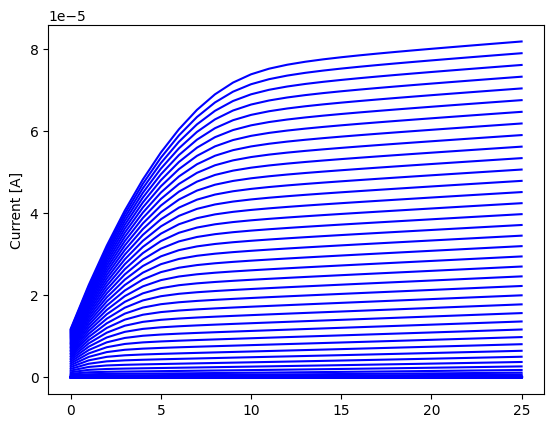

100%|██████████| 20000/20000 [09:02<00:00, 36.88it/s]


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import logging
from tqdm import tqdm
from src.get_first_device import get_first_device
from src.get_seperated_curves import get_seperated_curves
from src.plot_curves import plot_curves
from src.encoder import Encoder
from src.decoder import Decoder
from src.set_logger import set_logger
from src.get_reconstruction_loss import get_reconstruction_loss
from src.mlp import Mlp
from src.pretrain_latent_diffusion import pretrain_latent_diffusion
from src.visualize_0 import visualize_0
from src.get_20_devices import get_20_devices
from src.torch_dataset import TorchDataset

CSV_FILE = "nmos_130nm_gaussian_l_vth_rds_50_devs_into_subth.csv"
SEP = " "
DEVICE_DIM = 1378
CURRENT_COL = 3
VOLTAGE_0_DIM = 53
VOLTAGE_1_DIM = 26
LEARNING_RATE = 2e-4
EPOCHS = 20_000
LOGGING_FILE = "logs.log"
LOGGER_LEVEL = logging.INFO

dataframe = pd.read_csv(CSV_FILE, sep=SEP, header=None)
logger = set_logger(LOGGING_FILE, LOGGER_LEVEL)
torch_dataset = TorchDataset(
    dataframe,
    CURRENT_COL,
    DEVICE_DIM
)
train_loader = torch.utils.data.DataLoader(
    torch_dataset, batch_size=5
)

first_device_data = get_first_device(dataframe, DEVICE_DIM, CURRENT_COL)
separated_curves = get_seperated_curves(first_device_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
device = "cuda"

encoder = Encoder().to(device)
decoder = Decoder().to(device)

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LEARNING_RATE
)

first_device_data_tensor = torch.tensor(first_device_data, dtype=torch.float32)
mse_loss = torch.nn.MSELoss()

devices_20_data = get_20_devices(dataframe, DEVICE_DIM, CURRENT_COL) 
devices_20_data_tensor = torch.tensor(devices_20_data, dtype=torch.float32)

loss_list = []
for epoch in tqdm(range(EPOCHS)):
    train_loader_iter = iter(train_loader)
    for batch_index, dev_data in enumerate(train_loader):
    # for dev in devices_20_data_tensor:
        device_data = dev_data.to(torch.float32)
        device_data = device_data.to(device)
        latent_data = encoder(device_data)
        output_data = decoder(latent_data)

        loss = get_reconstruction_loss(output_data, device_data)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    loss_list.append(loss.item())

    if epoch % 1000 == 0:
        plt.plot(loss_list[-1000:])
        plt.title(f"Epoch {epoch}")
        plt.savefig(f"loss_epoch{epoch}.png")
        plt.close()
    
    if epoch % 100 == 0:
        logger.info(f"EPOCH: {epoch} LOSS: {loss.item()}")

In [12]:
feature_0_list = []
feature_10_list = []

samples_list = []
for i in range(30):
    samples_list.append([])

for i in range(len(torch_dataset)):
    features_vector_np = torch_dataset[i]
    features_vector_tensor = torch.tensor(features_vector_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        latent_tensor = encoder(features_vector_tensor)
    latent_numpy =  latent_tensor.cpu().numpy()

    for index in range(len(latent_numpy)):
        samples_list[index].append(latent_numpy[index])

# plt.plot(feature_0_list)
# plt.show()
# plt.plot(feature_10_list)
var_list = []
mean_list = []

var_0_count = 0

for i in range(len(samples_list)):
    var_val = np.var(samples_list[i])
    var_list.append(var_val)
    mean_list.append(np.mean(samples_list[i]))

    if np.isclose(var_val, 0.0):
        var_0_count += 1

for i in range(len(samples_list)):
    print(var_list[i])

0.0
0.0
0.0012435998
0.047369536
0.0014242384
0.05369451
0.05166597
0.046275526
0.046582323
0.054767102
0.0
0.0
0.0
0.0
0.042684473
0.046461597
0.0
0.04961822
0.049149256
0.0015927047
0.048996255
0.04051399
0.04297646
0.0
0.0
0.051706027
0.0012501725
0.049527243
0.0
0.02639585


In [13]:
for i in range(len(samples_list)):
    print(mean_list[i])

0.0
0.0
0.011238665
0.1491115
0.00993071
0.15989023
0.1786454
0.15394498
0.15390334
0.1742948
0.0
0.0
0.0
0.0
0.15018994
0.15463197
0.0
0.1665543
0.15982701
0.012830205
0.17178026
0.13312392
0.15297036
0.0
0.0
0.16315788
0.011862909
0.16954559
0.0
0.11583712


In [14]:
var_0_count

10

In [15]:
for i in range(len(samples_list)):
    print(f"VAR: {var_list[i]}  MEAN: {mean_list[i]}")

VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.0012435998069122434  MEAN: 0.01123866531997919
VAR: 0.04736953601241112  MEAN: 0.14911149442195892
VAR: 0.0014242384349927306  MEAN: 0.009930710308253765
VAR: 0.05369450896978378  MEAN: 0.15989023447036743
VAR: 0.05166596919298172  MEAN: 0.17864540219306946
VAR: 0.04627552628517151  MEAN: 0.1539449840784073
VAR: 0.04658232256770134  MEAN: 0.15390333533287048
VAR: 0.054767102003097534  MEAN: 0.17429479956626892
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.04268447309732437  MEAN: 0.15018993616104126
VAR: 0.046461597084999084  MEAN: 0.15463197231292725
VAR: 0.0  MEAN: 0.0
VAR: 0.04961822181940079  MEAN: 0.1665543019771576
VAR: 0.04914925619959831  MEAN: 0.15982700884342194
VAR: 0.0015927046770229936  MEAN: 0.012830205261707306
VAR: 0.04899625480175018  MEAN: 0.17178025841712952
VAR: 0.040513988584280014  MEAN: 0.13312391936779022
VAR: 0.042976461350917816  MEAN: 0.1529703587293625
VAR: 0.0  MEAN: 0.0

tensor([1.6844e-10, 3.6316e-10, 7.7881e-10,  ..., 1.2313e-04, 1.2708e-04,
        1.3103e-04], device='cuda:0')


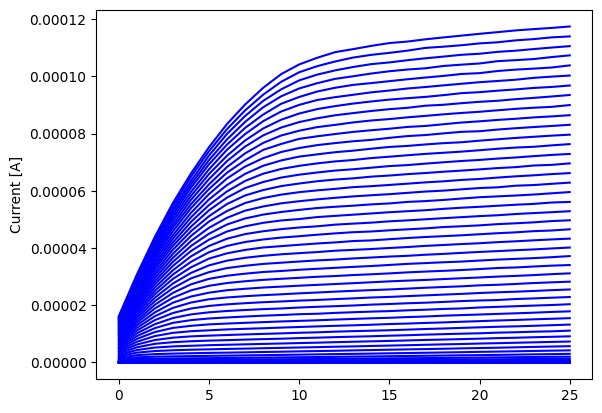

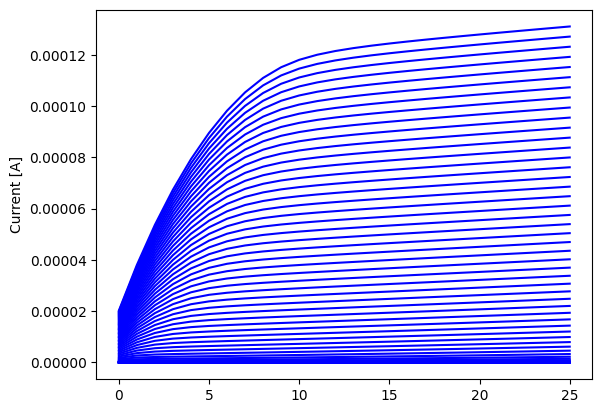

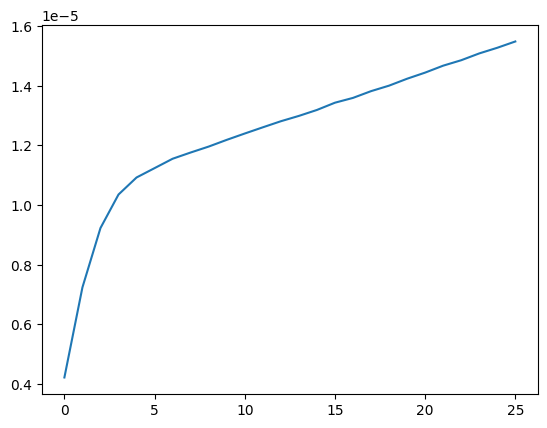

0.000117426374


In [20]:
encoder.eval()
decoder.eval()

data_for_encoder = torch_dataset[-10]
data_for_encoder = torch.tensor(data_for_encoder, dtype=torch.float32)
data_for_encoder = data_for_encoder.to(device)
# data_for_encoder = torch.zeros_like(data_for_encoder, dtype=torch.float32)
print(data_for_encoder)

with torch.no_grad():
    encoded_data = encoder(data_for_encoder)
    decoded_data = decoder(encoded_data)

decoded_data = decoded_data.cpu().numpy()
separated_curves = get_seperated_curves(decoded_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
separated_curves_1 = get_seperated_curves(data_for_encoder.cpu().numpy(), VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves_1)

plt.plot(separated_curves[20])
plt.show()
print(np.max(decoded_data))

In [11]:
# torch.save(encoder, "encoder_full_model.pth")
# torch.save(decoder, "decoder_full_model.pth")

In [30]:
TIMESTEPS = 40
EPOCHS = 300_000
mlp_model = Mlp(TIMESTEPS).to(device)
diffusion_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=LEARNING_RATE
)

betas = (torch.sigmoid(torch.linspace(-18, 10, TIMESTEPS)) * (3e-1 - 1e-5) + 1e-5)
alphas = 1 - betas
alphas_bar = torch.cumprod(alphas, dim=0)
first_device_data_tensor = first_device_data_tensor.to(device)

pretrain_latent_diffusion(mlp_model, encoder, first_device_data_tensor, diffusion_optimizer, EPOCHS, betas, alphas, alphas_bar, TIMESTEPS, logger, device)

100%|██████████| 300000/300000 [25:42<00:00, 194.53it/s]


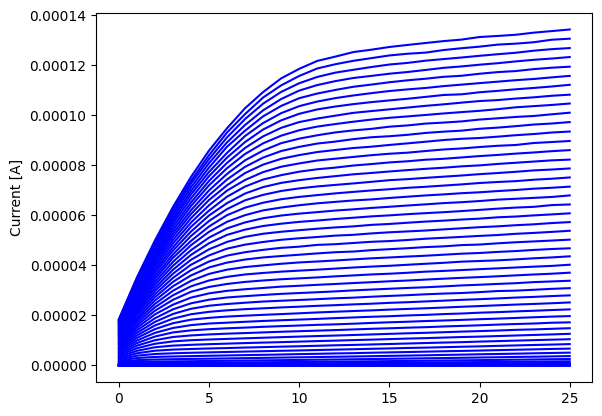

In [41]:
out_tensor = visualize_0(
    first_device_data_tensor,
    alphas_bar,
    betas,
    alphas,
    TIMESTEPS,
    mlp_model,
    encoder,
    decoder,
    device
)

out_numpy_data = out_tensor.cpu().numpy()

separated_curves = get_seperated_curves(out_numpy_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)

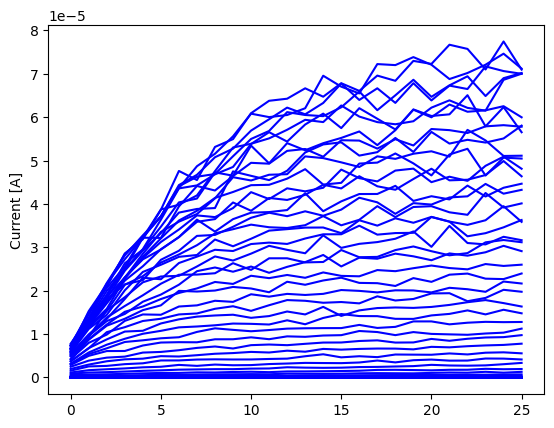

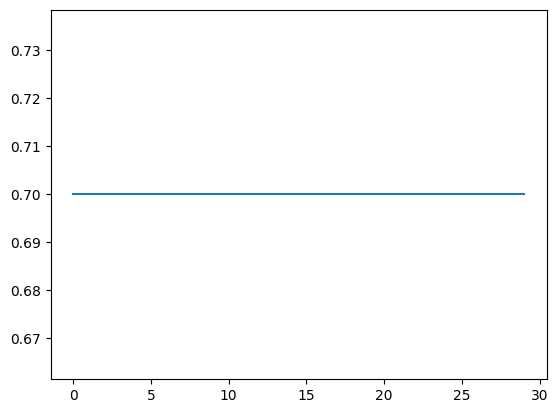

In [60]:
with torch.no_grad():
    test_data = torch.ones(30, dtype=torch.float32, device=device) * 0.7
    decoder_result = decoder(test_data)

decoder_result = decoder_result.cpu().numpy()

separated_curves = get_seperated_curves(decoder_result, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)

plt.show()
plt.plot(test_data.cpu().numpy())